*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 05 · S1 — Oracle Specification
Hypothesis: the pattern signals an actual reversal event; the oracle entry (on a gap bar, with look-ahead) provides the upper bound of the effect.

**Important:** S1 is non-causal by design: a gap bar can only be identified ex-post. This is a diagnostic tool, not a tradable strategy.
Composition: 1h oracle statistics + patterns → Test 0 (decomposition of the gap hour into 5m intervals) → yearly stability.
Prerequisites: artefacts 01–04 and data/processed/{asset}_5m.parquet (see data/README.md).

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd

from oivdc_research.config import get_config
import matplotlib.pyplot as plt   

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

In [2]:
from oivdc_research.forward_returns import load_forward_returns
from oivdc_research.event_selection import build_events_episodes_oracle
from oivdc_research.statistics import compute_statistics_for_events_wide, format_stats_table

df = load_forward_returns(CONFIG)
events_s1 = build_events_episodes_oracle(df, CONFIG)

s1_stats = compute_statistics_for_events_wide(
    events_s1, CONFIG, method_name="episodes", sample_type="nonoverlapping"
)
print(format_stats_table(s1_stats))

      method     sample_type signal_scope  horizon  n_events   winrate  \
0   episodes  nonoverlapping     combined        1     13474  0.661422   
1   episodes  nonoverlapping     combined        2     11200  0.601339   
2   episodes  nonoverlapping     combined        3      8933  0.585805   
3   episodes  nonoverlapping     combined        4      7439  0.573599   
4   episodes  nonoverlapping     combined        5      6368  0.573021   
5   episodes  nonoverlapping     combined       10      3715  0.549933   
6   episodes  nonoverlapping         long        1      6604  0.668534   
7   episodes  nonoverlapping         long        2      5483  0.612986   
8   episodes  nonoverlapping         long        3      4402  0.599046   
9   episodes  nonoverlapping         long        4      3699  0.575291   
10  episodes  nonoverlapping         long        5      3155  0.584469   
11  episodes  nonoverlapping         long       10      1776  0.564189   
12  episodes  nonoverlapping        sh

Expected behaviour: h=1 combined win rate ≈ 66%, p → 0; decay to h=10. Interpretation: the pattern signals a reversal event; the effect is concentrated within the gap bar.

Saved: reports/figures/s1/event_study_curve.png


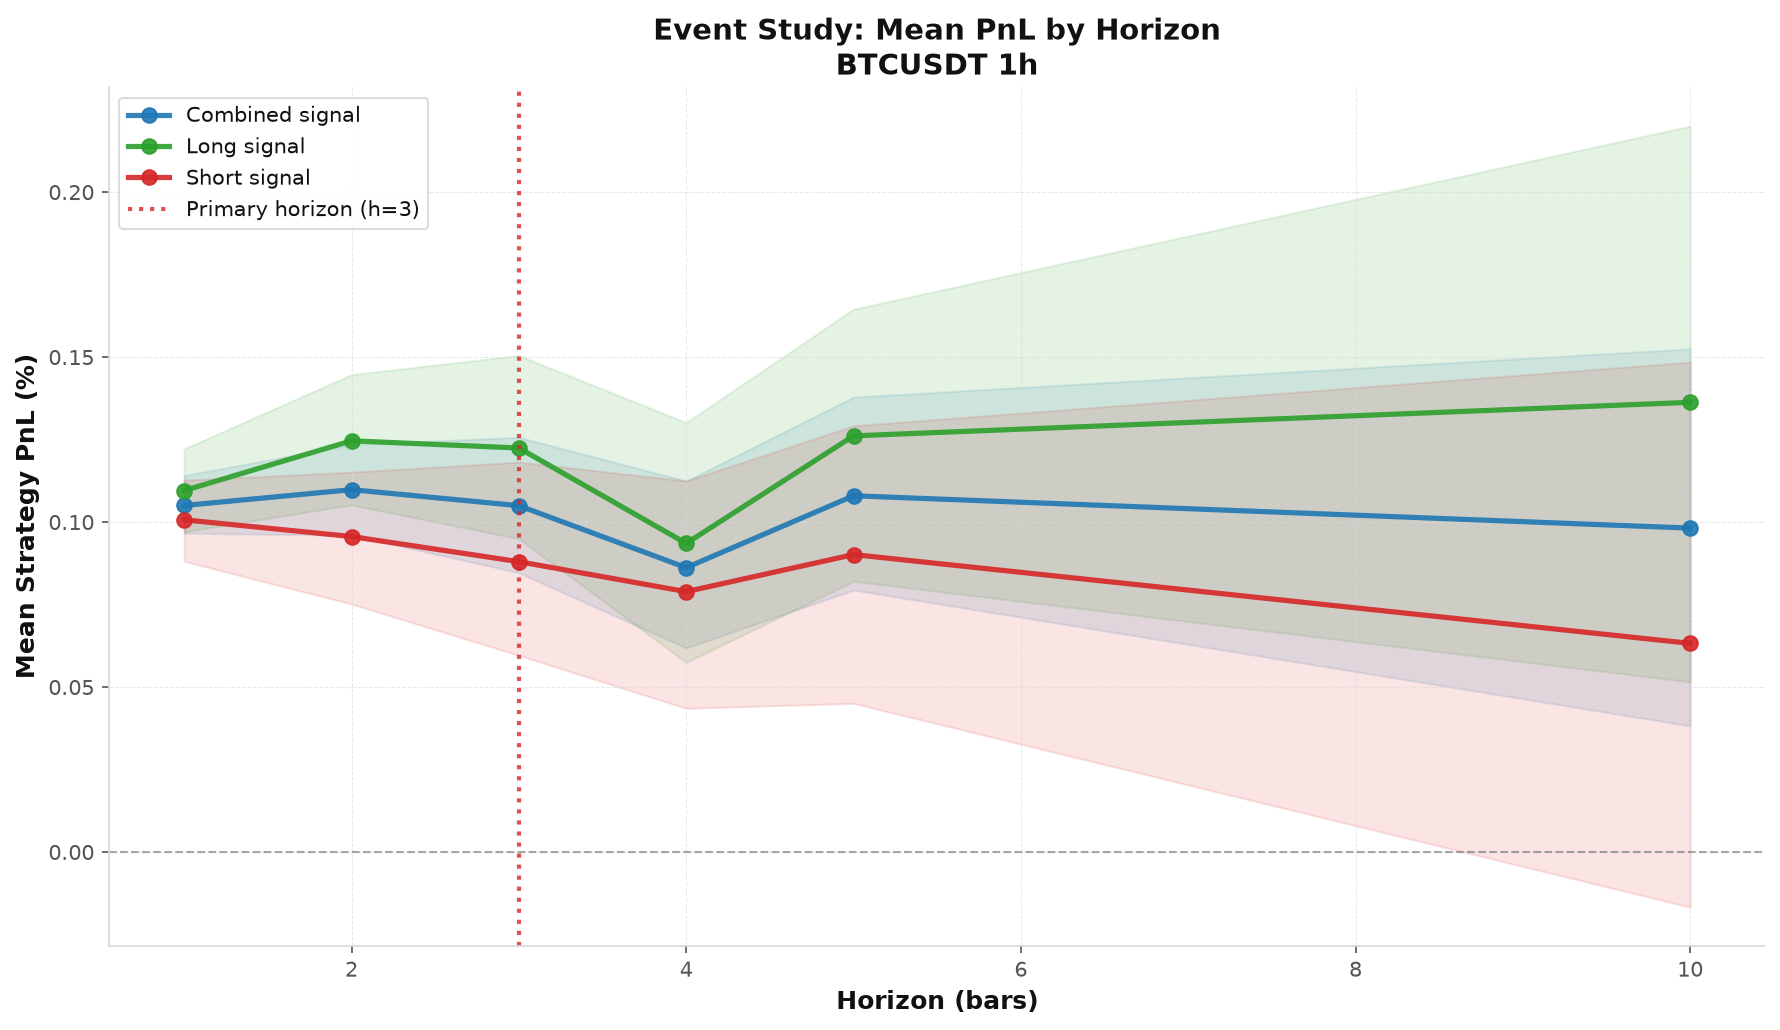

Saved: reports/figures/s1/winrate_by_horizon.png


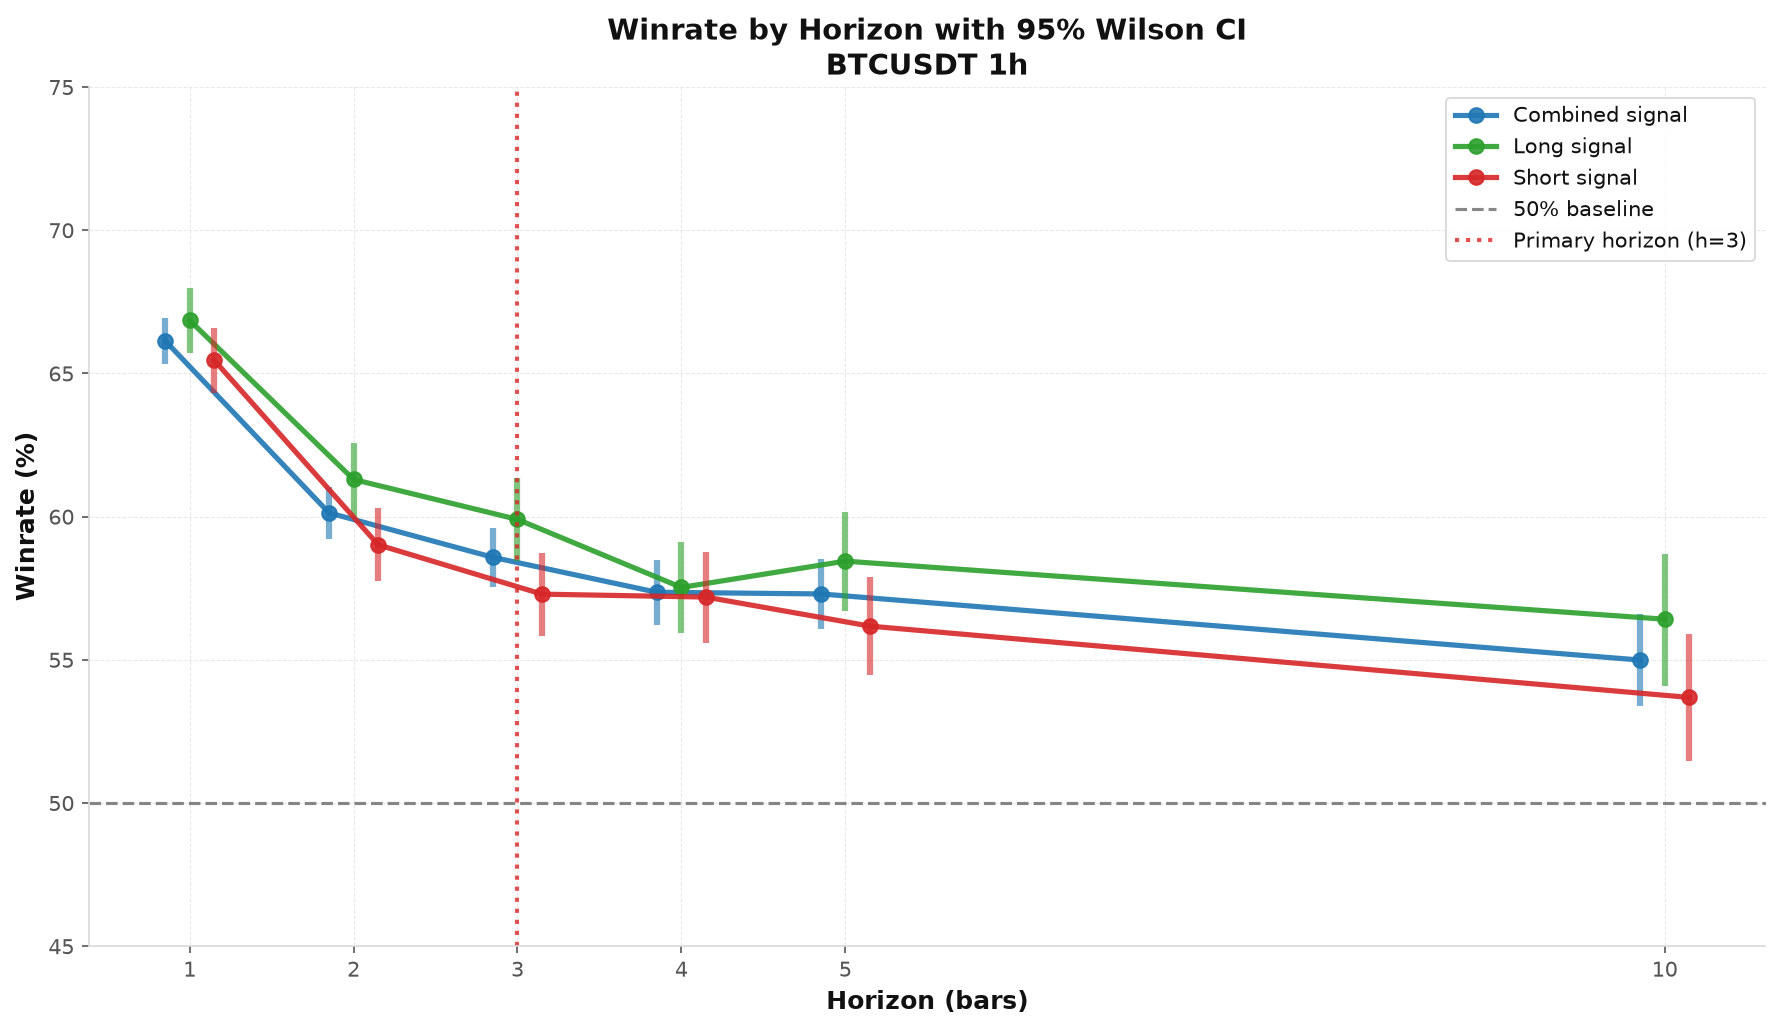

Saved: reports/figures/s1/pnl_distribution_h3.png


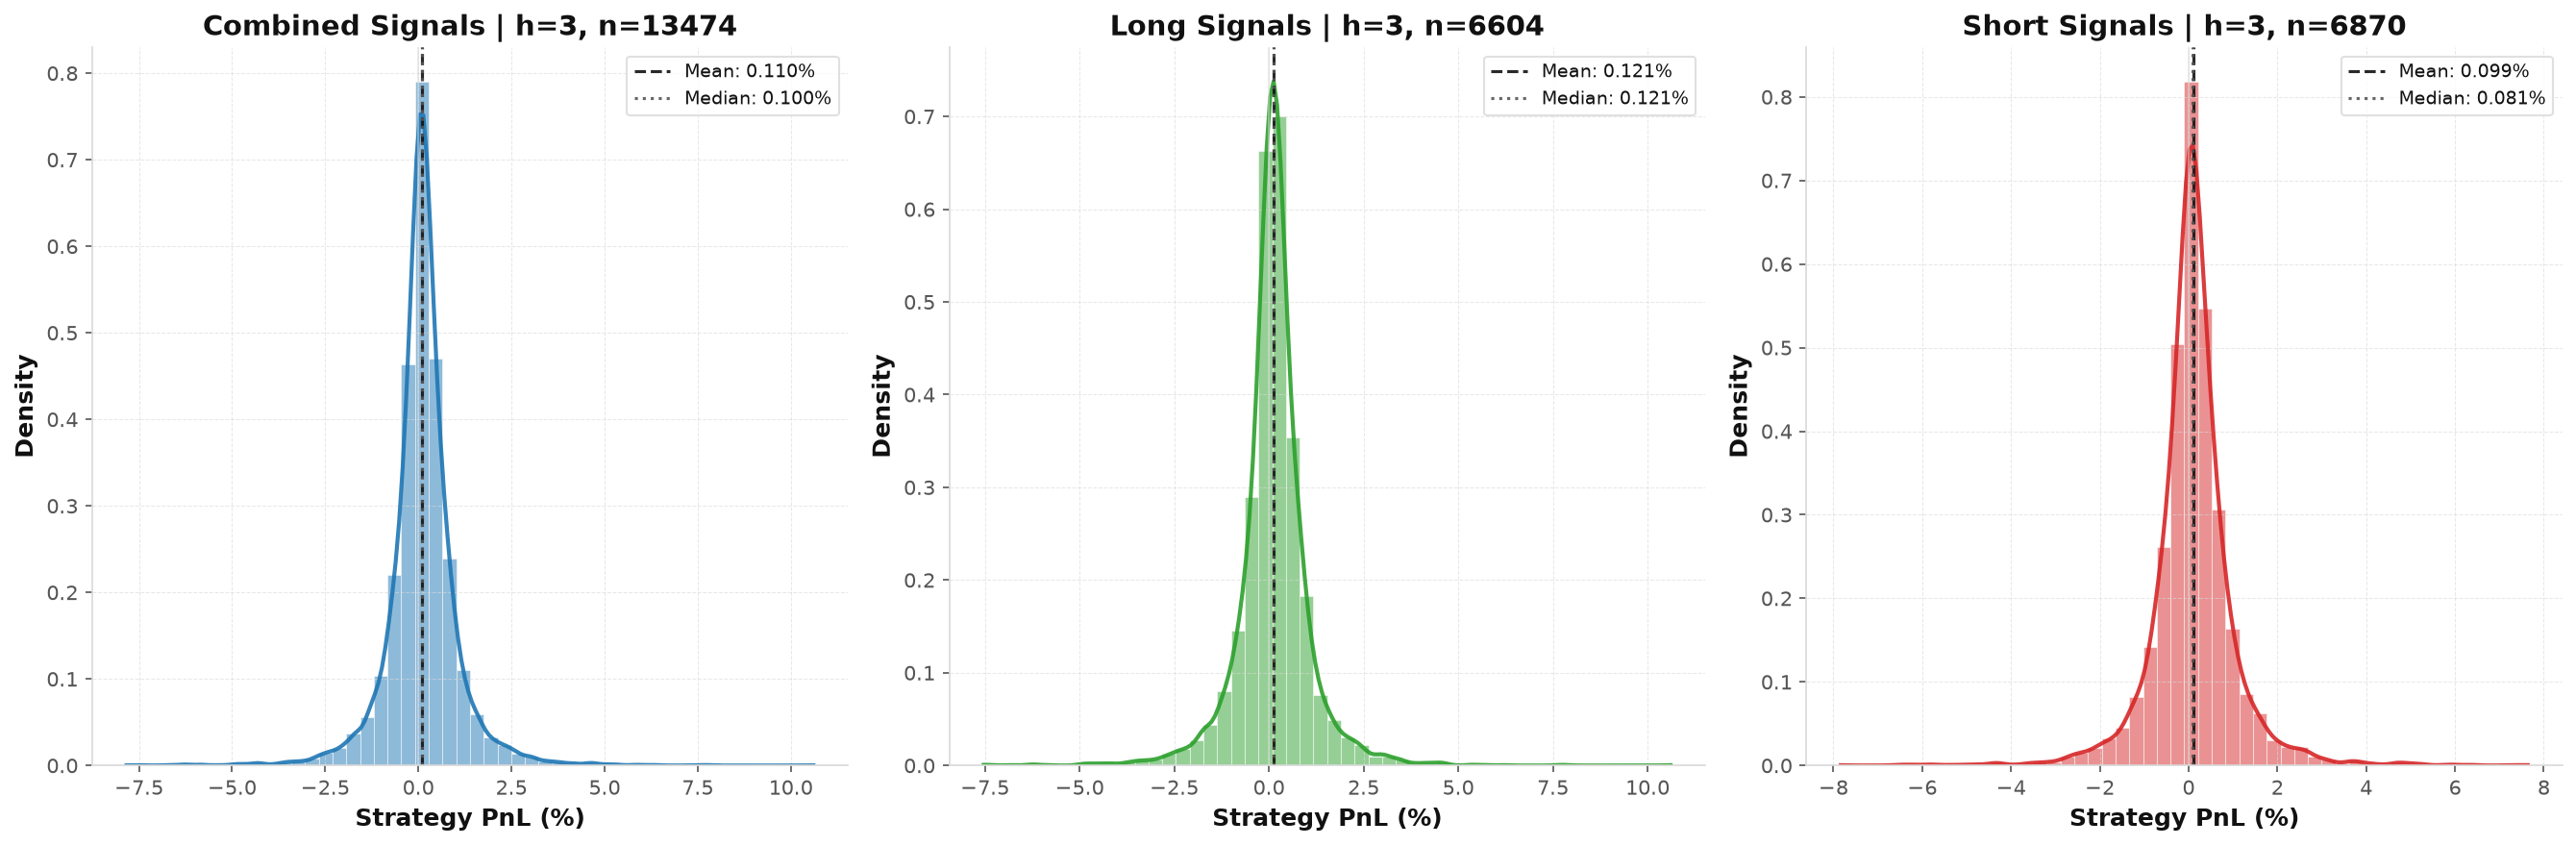

In [3]:
from oivdc_research.plotting import plot_event_study_curve, plot_winrate_by_horizon, plot_pnl_distribution

fig_dir = CONFIG.figures_dir_for("s1")
plot_event_study_curve(s1_stats, CONFIG, fig_dir / "event_study_curve.png")
plot_winrate_by_horizon(s1_stats, CONFIG, fig_dir / "winrate_by_horizon.png")
plot_pnl_distribution(events_s1, CONFIG, fig_dir / "pnl_distribution_h3.png")

#### Test 0 — where within a gap-hour does the reverse pattern reside? 
Decomposition of each gap-hour into 12 signed 5-minute segments. If the reverse pattern is smeared (idx50 ≈ 3–6), its start can theoretically be detected within the hour (motivation S4 at 08).

In [4]:
from oivdc_research.intrabar import hour_paths, extract_s1_events, collect_signed_paths, impulse_metrics
from oivdc_research.intrabar.data5m import load_5m_data

df5m = load_5m_data(CONFIG)   # ← готовый parquet из 01 Part B
hp = hour_paths(df5m)

s1_5m = extract_s1_events(df, CONFIG)
paths = collect_signed_paths(s1_5m, hp)
pd.Series(impulse_metrics(paths)).round(4)

n_events                      13474.0000
n_reversed                     8912.0000
share_reversed                    0.6614
idx50_median                      3.0000
idx80_median                      5.0000
single_jump_frac                  0.5300
mean_total_reversal               0.0034
median_total_reversal             0.0022
mean_max_5m_contribution          4.6562
median_max_5m_contribution        0.8482
dtype: float64

Saved: reports/figures/s1/impulse_structure.png


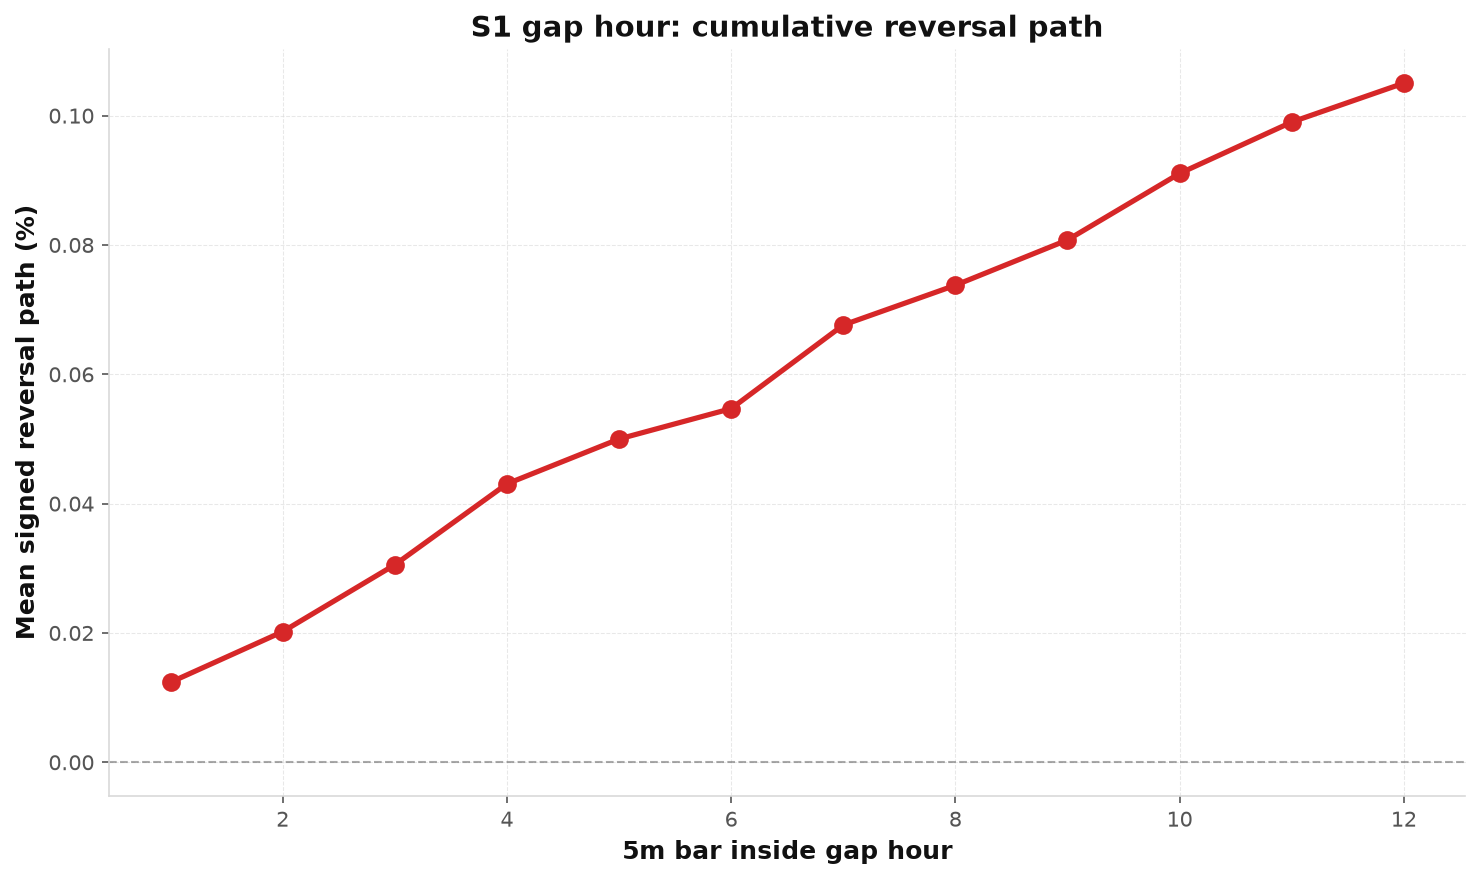

In [5]:
from oivdc_research.plotting import set_plot_style, get_palette, apply_axes_style, save_figure

set_plot_style(CONFIG.plot_theme)
pal = get_palette()

mean_path = paths.mean(axis=0) * 100
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 13), mean_path, marker="o", color=pal["accent"], linewidth=2.5)
ax.axhline(0, color=pal["text_secondary"], linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("5m bar inside gap hour")
ax.set_ylabel("Mean signed reversal path (%)")
ax.set_title("S1 gap hour: cumulative reversal path")
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, fig_dir / "impulse_structure.png")
plt.show()

#### Yearly stability. 
The proportion of reverse gap hours by year. A stable range of < 6pp ⇒ a regime-independent effect.

In [6]:
s1_yearly = s1_5m.copy()
s1_yearly["year"] = pd.to_datetime(s1_yearly["gap_ts"]).dt.year

rows = []
for year, sub in s1_yearly.groupby("year"):
    m = impulse_metrics(collect_signed_paths(sub, hp))
    rows.append({"year": year, **m})
df_yearly = pd.DataFrame(rows)

print(df_yearly[["year", "n_events", "share_reversed", "mean_total_reversal"]].to_string(index=False))
rng = df_yearly["share_reversed"].max() - df_yearly["share_reversed"].min()
print(f"Range: {rng:.3f}, Std: {df_yearly['share_reversed'].std():.3f}")

 year  n_events  share_reversed  mean_total_reversal
 2021      1225        0.640816             0.004506
 2022      2527        0.673130             0.004003
 2023      2453        0.651447             0.002592
 2024      2800        0.655000             0.003695
 2025      2779        0.667506             0.002939
 2026      1690        0.673964             0.003022
Range: 0.033, Std: 0.013


Saved: reports/figures/s1/yearly_stability.png


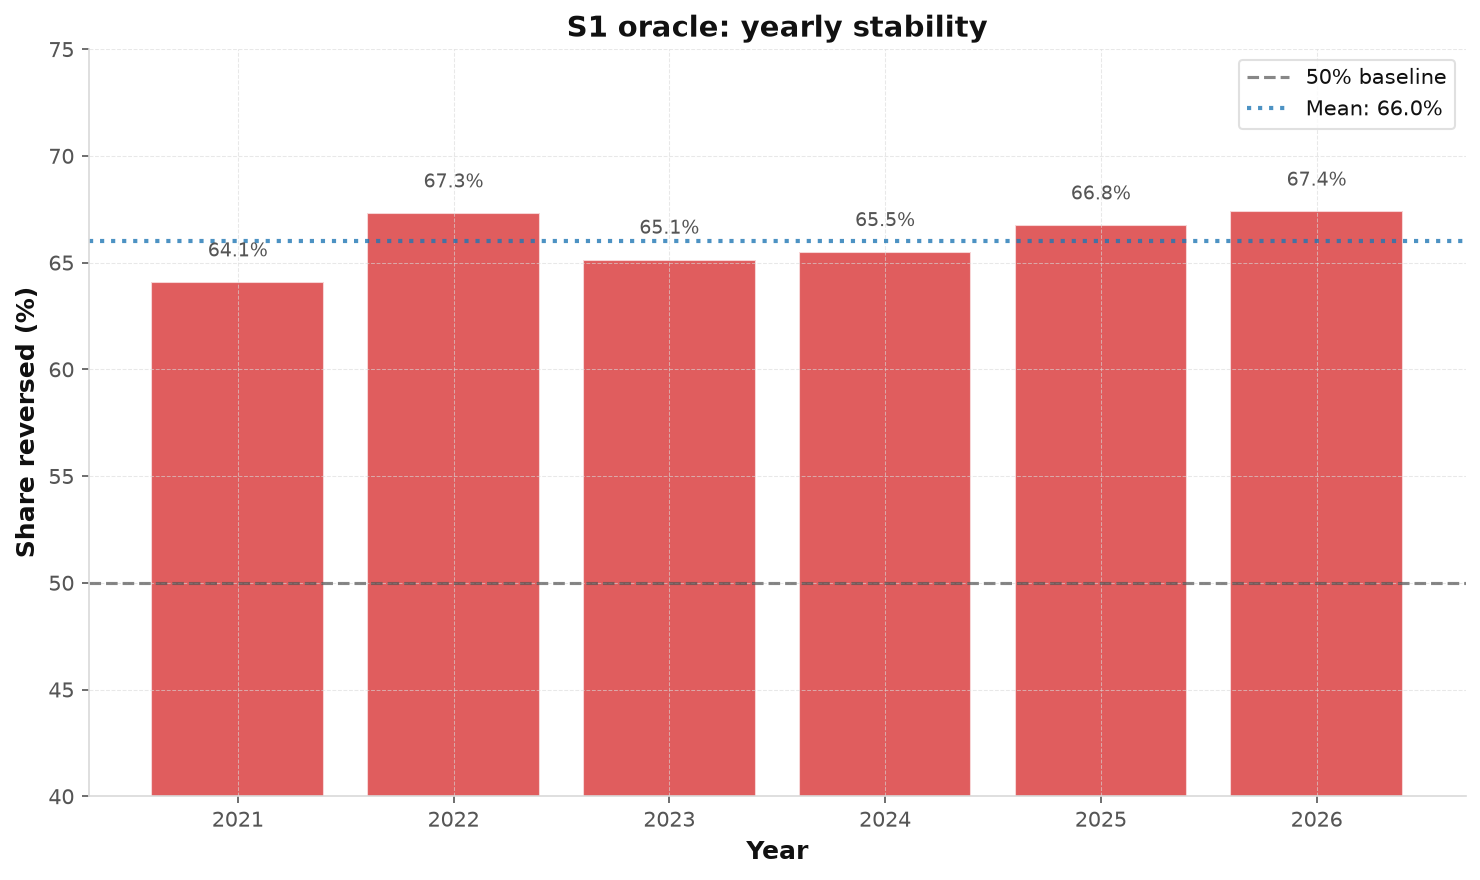

In [7]:
set_plot_style(CONFIG.plot_theme)
pal = get_palette()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df_yearly["year"].astype(str), df_yearly["share_reversed"] * 100,
              color=pal["accent"], alpha=0.75, edgecolor=pal["background"])
ax.axhline(50, color=pal["text_secondary"], linestyle="--", linewidth=1.5, alpha=0.7,
           label="50% baseline")
ax.axhline(df_yearly["share_reversed"].mean() * 100, color=pal["combined"],
           linestyle=":", linewidth=2, alpha=0.8,
           label=f"Mean: {df_yearly['share_reversed'].mean()*100:.1f}%")
for bar, val in zip(bars, df_yearly["share_reversed"] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9,
            color=pal["text_secondary"])
ax.set_xlabel("Year")
ax.set_ylabel("Share reversed (%)")
ax.set_title("S1 oracle: yearly stability")
ax.set_ylim(40, 75)
ax.legend()
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, fig_dir / "yearly_stability.png")
plt.show()

Conclusions 05: (1) the oracle effect is strong and stable over the years; (2) the reversal is spread out over an hour (idx50 ≈ 3, idx80 ≈ 5) — it is not a single jump; (3) S1 is non-tradable ⇒ we move on to causal specifications (06).